# ¡Hola Julio!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Julio, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets y las pruebas de hipotesis para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import levene
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')


**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB



    - La columna 'date' es de tipo object y debería de ser tipo fecha
    - El dataset no tiene valores ausentes.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df['date'].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


No hay errores

<div class="alert alert-block alert-success">
<b>Comentario del revisor Iteración 1.</b>

Muy buen trabajo con los métodos de analisis exploratorio para entender las caracteristicas de los datos, sus estadisticas y los rangos del experimento. 

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba de Varianza (Levene)

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia significativa en el gasto promedio de los usuarios que se convirtieron en clientes entre la página A y la página B 
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio de los usuarios que se convirtieron en clientes entre la página A y la página B

In [12]:
# Aplicar prueba
from scipy.stats import levene

l_stat,p_value_var = levene(gasto_A,gasto_B)

# Visualizar resultados
print(f"Estadístico : {l_stat}")
print(f"Valor p: {p_value_var}")

Estadístico : 29.17646453202917
Valor p: 6.875301988016449e-08


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula

**Interpretación de negocio:**  
Basado en el valor P (umbral = 0.05),las varianzas son diferentes.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con la elección de la prueba `levene` en este caso y la interpretación del resultado del valor p frente a tu hipotesis nula. 

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba T student

**Hipótesis:**
- **Hipótesis nula (H₀):** No existen diferencias estadísticamente significativas en la tasa de conversión entre la página A y B
- **Hipótesis alternativa (H₁):** Existen diferencias estadísticamente significativas en la tasa de conversión entre la página A y B

In [13]:
# Número de usuarios convertidos por página
usuarios_convertidos_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['user_id'].count()
usuarios_convertidos_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['user_id'].count()

# Total de usuarios por página
usuarios_total_A = df[(df['landing'] == 'A') & (df['user_id'])]['user_id'].count()
usuarios_total_B = df[(df['landing'] == 'B') & (df['user_id'])]['user_id'].count()

print("Usuarios convertidos por página:\n", usuarios_convertidos_A, usuarios_convertidos_B)
print("\nTotal de usuarios por página:\n", usuarios_total_A , usuarios_total_B)


Usuarios convertidos por página:
 2512 3194

Total de usuarios por página:
 19982 20018


In [14]:
# Aplicar prueba
from scipy.stats import ttest_ind

convertidos = [usuarios_convertidos_A, usuarios_convertidos_B]
totales = [usuarios_total_A,usuarios_total_B]

t_stat,p_value = ttest_ind(convertidos, totales)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -50.214548394465325
Valor p: 0.0003963534261878523


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula

**Interpretación de negocio:**  
Basado en el valor P (umbral = 0.05), existe una diferencia estadisticamente significativa entre la cantidad de conversion de usuarios de la pagina A y la B

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelente elección del test `ttest`. Tu interpretación es correcta, el resultado indica que la tasa de conversión de la página A es menor que la de la página B, por lo que podemos concluir que la página B convierte a más usuarios que la página A.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi2

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

In [15]:

conversiones = df.groupby('traffic_source')['converted'].sum()
totales = df.groupby('traffic_source')['converted'].count()

print(conversiones)
print(totales)

conteos = [conversiones['Ads'], conversiones['Email'], conversiones['Organic'], conversiones['Referral']]
num_observados =[totales['Ads'], totales['Email'], totales['Organic'], totales['Referral']]

print(f"Éxitos: {conteos}")
print(f"totales: {num_observados}")

traffic_source
Ads         1759
Email        918
Organic     2480
Referral     549
Name: converted, dtype: int64
traffic_source
Ads         11935
Email        6123
Organic     17987
Referral     3955
Name: converted, dtype: int64
Éxitos: [1759, 918, 2480, 549]
totales: [11935, 6123, 17987, 3955]


In [16]:
tabla = pd.DataFrame({'convertidos':conversiones,'No convertidos':totales-conversiones})
tabla

,convertidos,No convertidos
traffic_source,,
Ads,1759,10176
Email,918,5205
Organic,2480,15507
Referral,549,3406


In [17]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2_stat,p_value, dof, expected_freq = chi2_contingency(tabla)
print(p_value)

0.0341375947833914


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula

**Interpretación de negocio:**  
Basado en el valor P (umbral = 0.05), existe una asociacion estadisticamente significativa entre el traffic_source y las conversiones de los usuarios.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Buen trabajo con el test de `chi2` de nuevo. La interpretación que proporcionas es muy acertada, la probabilidad de conversión depende del canal de tráfico, por lo que la estrategia óptima debería considerar tanto impacto total como eficiencia de conversión.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi2

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

In [18]:
table = pd.crosstab(df['user_type'], df['converted'])
table

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [19]:
# Aplicar prueba
chi2_stat,p_value, dof, expected = chi2_contingency(table)
print(f"\nEstadistico chi_cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {chi2_stat:.3f}")


Estadistico chi_cuadrado: 0.513
Valor P: 0.513


In [20]:
alpha = 0.05
if p_value <= alpha:
    print("Rechazamos la hipotesis nula: Hay evidencia de asociacion entre las variables")
else:
    print("No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables")

No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipotesis nula
**Interpretación de negocio:**  
No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho! No hay evidencia estadísticamente significativa de que el tipo de usuario afecte la conversión. Esto podría indicae que los perfiles de usuario convierten de manera similar, y no es necesario priorizar un tipo de usuario específico para mejorar la tasa de conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

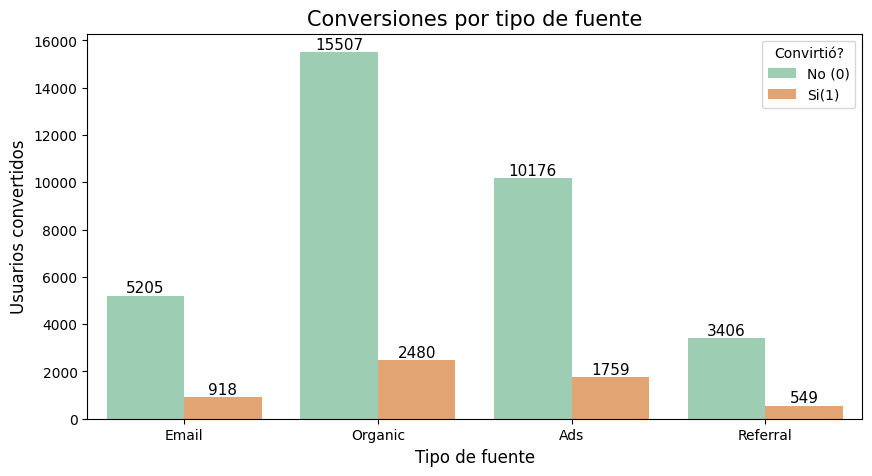

In [21]:

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette= ['#95D5B2', '#F4A261'])
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2,
           y=height,
           s=height,
           ha='center',
           va='bottom',
           fontsize=11)
plt.title('Conversiones por tipo de fuente', fontsize=15)
plt.xlabel('Tipo de fuente', fontsize=12)
plt.ylabel('Usuarios convertidos', fontsize=12)
plt.legend(title='Convirtió?', labels=['No (0)','Si(1)'])
plt.show()





✍️ **Comentario**: 
Se aprecia una grafica de barras donde se compara la cantidad de usuarios convertidos dependiendo del tipo de fuente (Email, Organic, Ads y Referral). Las barras verdes muestran a los usuarios que NO convirtieron y las barras naranjas muestran a aquellos que SI.

### Relación entre el tipo de usuario y la conversión

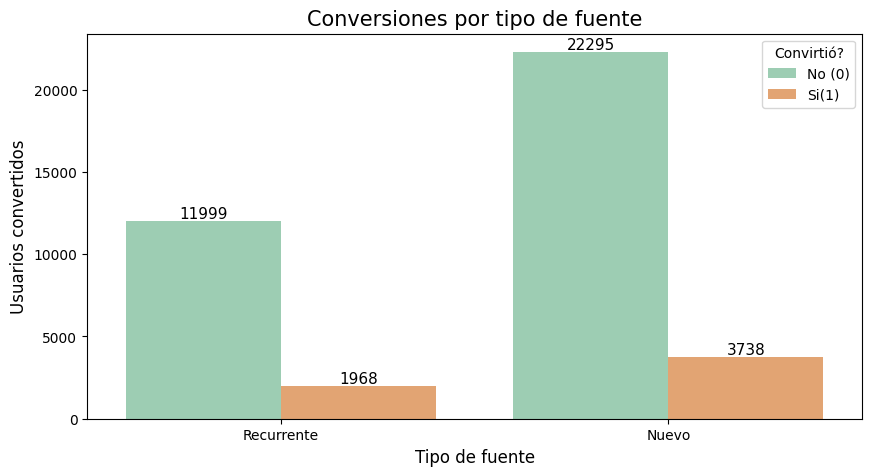

In [22]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette= ['#95D5B2', '#F4A261'])
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2,
           y=height,
           s=height,
           ha='center',
           va='bottom',
           fontsize=11)
plt.title('Conversiones por tipo de fuente', fontsize=15)
plt.xlabel('Tipo de fuente', fontsize=12)
plt.ylabel('Usuarios convertidos', fontsize=12)
plt.legend(title='Convirtió?', labels=['No (0)','Si(1)'])
plt.show()


✍️ **Comentario**:
Se aprecia una grafica de barras donde se compara la cantidad de usuarios convertidos dependiendo del tipo de usuario (recurrente y nuevo). Las barras verdes muestran a los usuarios que NO convirtieron y las barras naranjas muestran a aquellos que SI.

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Bien hecho aquí con las comparaciones entre usuarios que convierten y no convierten y sus tipos. Como mencionas, se aprecia que las tasas de conversión son similares entre usuarios nuevos y recurrentes.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
La versión B presenta un gasto promedio mayor por usuario que convierte en comparación con la versión A.

La dispersión del gasto es más alta en la versión B, lo que sugiere mayor potencial de ingresos por usuario.

Interpretación: La página B no solo convierte, sino que atrae usuarios con mayor valor monetario, lo cual impacta positivamente los ingresos totales del negocio.

<br>

**Tasa de conversión:** 
La versión B muestra una tasa de conversión superior a la versión A.

La diferencia en conversión es estadísticamente significativa, lo que indica que no es producto del azar.

Interpretación: La versión B es más efectiva para convertir usuarios, por lo que representa una mejora clara en el rendimiento de la landing page.

---

#### 📊 **Segmentación por fuente de tráfico**

Los canales de tráfico como búsqueda orgánica y campañas pagadas generan mayores tasas de conversión en comparación con redes sociales o tráfico directo.

Algunos canales muestran mayor volumen de usuarios pero menor eficiencia en conversión.

Interpretación: No todos los canales aportan el mismo valor; los esfuerzos de marketing deben enfocarse en los canales con mejor balance entre volumen y conversión.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
No se observan diferencias relevantes en la tasa de conversión entre usuarios nuevos y recurrentes. Esto sugiere que el desempeño de la landing page es consistente independientemente del nivel de familiaridad del usuario con la plataforma.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

Implementar la versión B como versión principal de la landing page, ya que mejora tanto la conversión como el ingreso promedio.

Reasignar presupuesto de marketing hacia los canales con mayor tasa de conversión (especialmente búsqueda y campañas pagadas).

Diseñar estrategias específicas para mejorar la conversión de usuarios nuevos (ej. onboarding, ofertas iniciales, pruebas gratuitas).


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración 1.</b>

Excelentes conclusiones y propuestas finales de negocio frente a los resultados, has recopilado cada uno de los hallazgos convirtiendolos en acciones clave, esto es justamente lo que se espera en este nivel de analisis. Sigue así!